# Recreating iPad Graphics with Plotnine (part 2)

## Introduction

For the last six years, I have been collecting rainfall data at Coolum Beach, Queensland.  I have been processing the data on an iPad, using Apple Numbers, and generating a number of charts and graphs.

I decided to see how hard it would it would be to use Plotnine to generate similar charts.  Most of the iPad charts have been heavily modified from the defaults, via the tweaking user interface (things like colors, line widths, etc).  The main aim of the charts is to see if there any visible patterns in the rainfall.

This is the second part of this exploration

## Implementation

### Set up Notebook magics

```lab_black``` formats the code, ```watermark``` provides reproducability information

In [1]:
%load_ext lab_black

In [2]:
%load_ext watermark

### Import libraries

I am not a great fan of ```from plotnine import *```, and I decided that all Plotnine methods would be explicitly declared.  It make the code a triffle more verbose, but also makes it clear what is coming from Plotnine

In [3]:
import pandas as pd
import numpy as np
import plotnine as p9

-----------------------

## Read Data

The iPad spreadsheet can be converted to Excel format for export.  We specify:

+ the spreadsheet name
+ the tab or sheet with the spreadsheet
+ the column numbers that we want from that sheet
+ the data types of each colum (if needed)
+ the numer of rows to process
+ the number of initial rows to skip
+ the names of the columns in the resulting DataFrame
+ where the original iPad sheet has an empty cell, Excel / Pandas gives me Not-A-Number.  I convert these to zeros with the ```fillna()``` call

In fact, the iPad spreadsheet contains many tabs as I found it easier to have a single data entry tab, and then to compute averages, etc, in separate tables in seperate tabs.  This made creating iPad charts vastly easier. 

```DoY``` is the day number within any given year (running 1-366 in leap years, 1-365 otherwise).

In [4]:
SS_PATH = "data/Rainfall 4.xlsx"
SHEET = "Data Entry"
type_dict = {"Day of Year": int}

rain_df = pd.read_excel(
    SS_PATH,
    SHEET,
    usecols=[0, 4, 5, 6, 7, 8, 9, 10],
    dtype=type_dict,
    nrows=366,
    skiprows=3,
    names=[
        "DoY",
        "2020",
        "2021",
        "2022",
        "2023",
        "2024",
        "2025",
        "2026",
    ],
    header=None,
).fillna(0)

### Examine the imported DataFrame

Show the first few rows

In [5]:
rain_df.head(2)

,DoY,2020,2021,2022,2023,2024,2025,2026
0,1,0.0,24.0,16.0,0.0,0.0,0.5,2.5
1,2,0.0,0.0,7.0,0.0,92.0,1.5,0.0


Show the last few rows

In [6]:
rain_df.tail(2)

,DoY,2020,2021,2022,2023,2024,2025,2026
364,365,5.5,0.5,4.0,66.0,15.0,0.0,0.0
365,366,22.0,0.0,0.0,0.0,0.0,0.0,0.0


Confirm the column names are really strings

In [7]:
rain_df.columns

Index(['DoY', '2020', '2021', '2022', '2023', '2024', '2025', '2026'], dtype='object')

Check the data types of the columns

In [8]:
rain_df.dtypes

DoY       int64
2020    float64
2021    float64
2022    float64
2023    float64
2024    float64
2025    float64
2026    float64
dtype: object

----------------------
## Convert DataFrame from ```wide``` to ```long```

Plotnine is based upon ```ggplot2```, which is part of the ```R``` and ```tidy``` universe.  This universe has a very strong opinion about DataFrame layout:  there is only one column that holds observed data of a given type, and the other columns in any given row describe / specify the context of the observation.

So in my DataFrame above, I have broken this rule.  I have multiple columns (one for each year) that hold rainfall observations:  we now set about transforming my DataFrame from ```wide``` format to ```long``` format.

### DateTimes from Day of Year and Year
We do a trial run of generating a date string consisting of a 4 digit year followed by a day-of-year (DoY).  We use Pandas function to turn the DoY values into a string, and the Pandas ```to_datetime``` method, using the codes for string-to-date formatting (```%Y% -> four digit year, ```%j%``` -> day-of-year).  For the first year column (2020, a leap year), this works OK, spanning the whole year.

In [9]:
year_str = rain_df.columns[1]
pd.to_datetime(
    year_str + rain_df["DoY"].astype(str), format="%Y%j"
)

0     2020-01-01
1     2020-01-02
2     2020-01-03
3     2020-01-04
4     2020-01-05
         ...    
361   2020-12-27
362   2020-12-28
363   2020-12-29
364   2020-12-30
365   2020-12-31
Name: DoY, Length: 366, dtype: datetime64[ns]

Things are a little less happy for non-leap years.  My iPad spreadsheet has DoY running from 1 to 366, so the generated DateTime array has its last value in the next year.

In [10]:
year_str = '2021'
pd.to_datetime(
    year_str + rain_df["DoY"].astype(str), format="%Y%j"
)

0     2021-01-01
1     2021-01-02
2     2021-01-03
3     2021-01-04
4     2021-01-05
         ...    
361   2021-12-28
362   2021-12-29
363   2021-12-30
364   2021-12-31
365   2022-01-01
Name: DoY, Length: 366, dtype: datetime64[ns]

We now create a seperate Pandas DataFrame for each year, with special handling for non-leap years (we skip the last row, corresponding to day-of-year 366)

In [11]:
# list of Pandas dataframe, one for each year
year_dfs = []

# loop over all years in our loaded-from-excel dataframe
for y in rain_df.columns[1:-1]:
    # indicate progress
    print(f'Doing year {y}')

    # convert the day-of-year numbers for this year into datetimes, parsing generated strings
    year_dates = pd.to_datetime(
        y + rain_df["DoY"].astype(str), format="%Y%j"
    )

    # handle non-leap years by skipping last value (day-of-year = 366 no valid for a non-leap year)
    if int(y) % 4 == 0:
        year_rain = rain_df[y]
    else:  # not a leap year
        year_dates = year_dates[:-1]
        year_rain = rain_df[y][:-1]
    # end if

    # build a dataframe from two arrays, datetime values, and rainfall values
    year_df = pd.DataFrame(
        {'date': year_dates, 'rain': year_rain}
    )
    # add to list of dataframes
    year_dfs.append(year_df)
# end for

Doing year 2020
Doing year 2021
Doing year 2022
Doing year 2023
Doing year 2024
Doing year 2025


Check the last few rows of the last dataframe in list - looks OK

In [12]:
year_dfs[-1].tail(2)

,date,rain
363,2025-12-30,0.0
364,2025-12-31,0.0


### Build ```long``` DataFrame
We now use Pandas to concatenate to multiple DataFrames we have built.

In [13]:
rain_df2 = pd.concat(year_dfs)

Check the first few rows, and last few rows.  Dates and rainfall values look OK.

In [14]:
rain_df2.head(2)

,date,rain
0,2020-01-01,0.0
1,2020-01-02,0.0


In [15]:
rain_df2.tail(2)

,date,rain
363,2025-12-30,0.0
364,2025-12-31,0.0


-----------------------------

## Weekly data

The wheels come off my export of the iPad numbers spreadsheet to Excel, when it comes to weeks.  I really just wanted to chunk the year up into 7 day chunks, but used the built-in __WEEKNUM__ function. These function have hidden complexity: to quote Microsoft abouts its __WEEKNUM__ function (that the export-to-Excel spreadsheet uses):

> There are two systems used for this function:

> System 1    The week containing January 1 is the first week of the year, and is numbered week 1.
> 
> System 2    The week containing the first Thursday of the year is the first week of the year, and is numbered as week 1.
> This system is the methodology specified in ISO 8601, which is commonly known as the European week numbering system.

I further confused the issue by using the Pandas __isocalendar__ __week__ attribute.  All this meant that for a given day of the year, the week number assigned could vary from iPad to Excel to Pandas.  Thus the plots Plotnine produces (via Pandas) are slightly different to the iPad plots.

Check the DataFrame first few rows

In [16]:
rain_df2.head(2)

,date,rain
0,2020-01-01,0.0
1,2020-01-02,0.0


In order to plot the cumulative rainfall for each year, we define a new column ```year```, and to group by week, we need a new column ```week```

In [17]:
rain_df2['year'] = rain_df2['date'].dt.year

rain_df2['week'] = rain_df2['date'].dt.isocalendar().week

Check the first and last few rows: looks OK - note that the last few days are considered to be in week one of the next year isocalendar-wise, but Excel considers them to be in week 53 of the year.  We run with the Pandas definition, it doesn't change the plots much.

In [18]:
rain_df2.head(2)

,date,rain,year,week
0,2020-01-01,0.0,2020,1
1,2020-01-02,0.0,2020,1


In [19]:
rain_df2.tail(5)

,date,rain,year,week
360,2025-12-27,4.5,2025,52
361,2025-12-28,7.0,2025,52
362,2025-12-29,0.5,2025,1
363,2025-12-30,0.0,2025,1
364,2025-12-31,0.0,2025,1


Extract just the columns we want, group by __year__ and __week__ within __year__, sum the data, and check the first few rows.  Resetting the index after a groupby operation is good practice

In [20]:
w_rain = (
    rain_df2[['rain', 'year', 'week']]
    .groupby(['year', 'week'])
    .sum()
    .reset_index(level=['year', 'week'])
)
w_rain.head(2)

,year,week,rain
0,2020,1,0.0
1,2020,2,0.0


Check the data types.  We will want to change these to make using Plotnine easier

In [21]:
w_rain.dtypes

year      int32
week     UInt32
rain    float64
dtype: object

We turn the __week__ column to ordinary (Python) ints, and make the __year__ column a categorical column (so Plotnine knows it is a set of discrete values, and not a continuous range of values.

In [22]:
w_rain['week'] = w_rain['week'].astype(int)

w_rain['year'] = w_rain['year'].astype('category')

Set the width and height of our plots

In [23]:
width, height = (12, 6)

We:

+ create an empty plot object, setting our data source to be the weekly rain DataFrame __w_rain__
+ add columns, x-axis position mapped to the __week__ column, height mapped to the __rain__ column, with color set by the __year__ column
+ set the columns to be side by side (not stacked)
+ set the column width to leave a small space between weeks
+ set a theme of black & white (no gray fill)
+ set the plot size
+ set the x axis tick marks and l;abels to be all values between 1 and 53

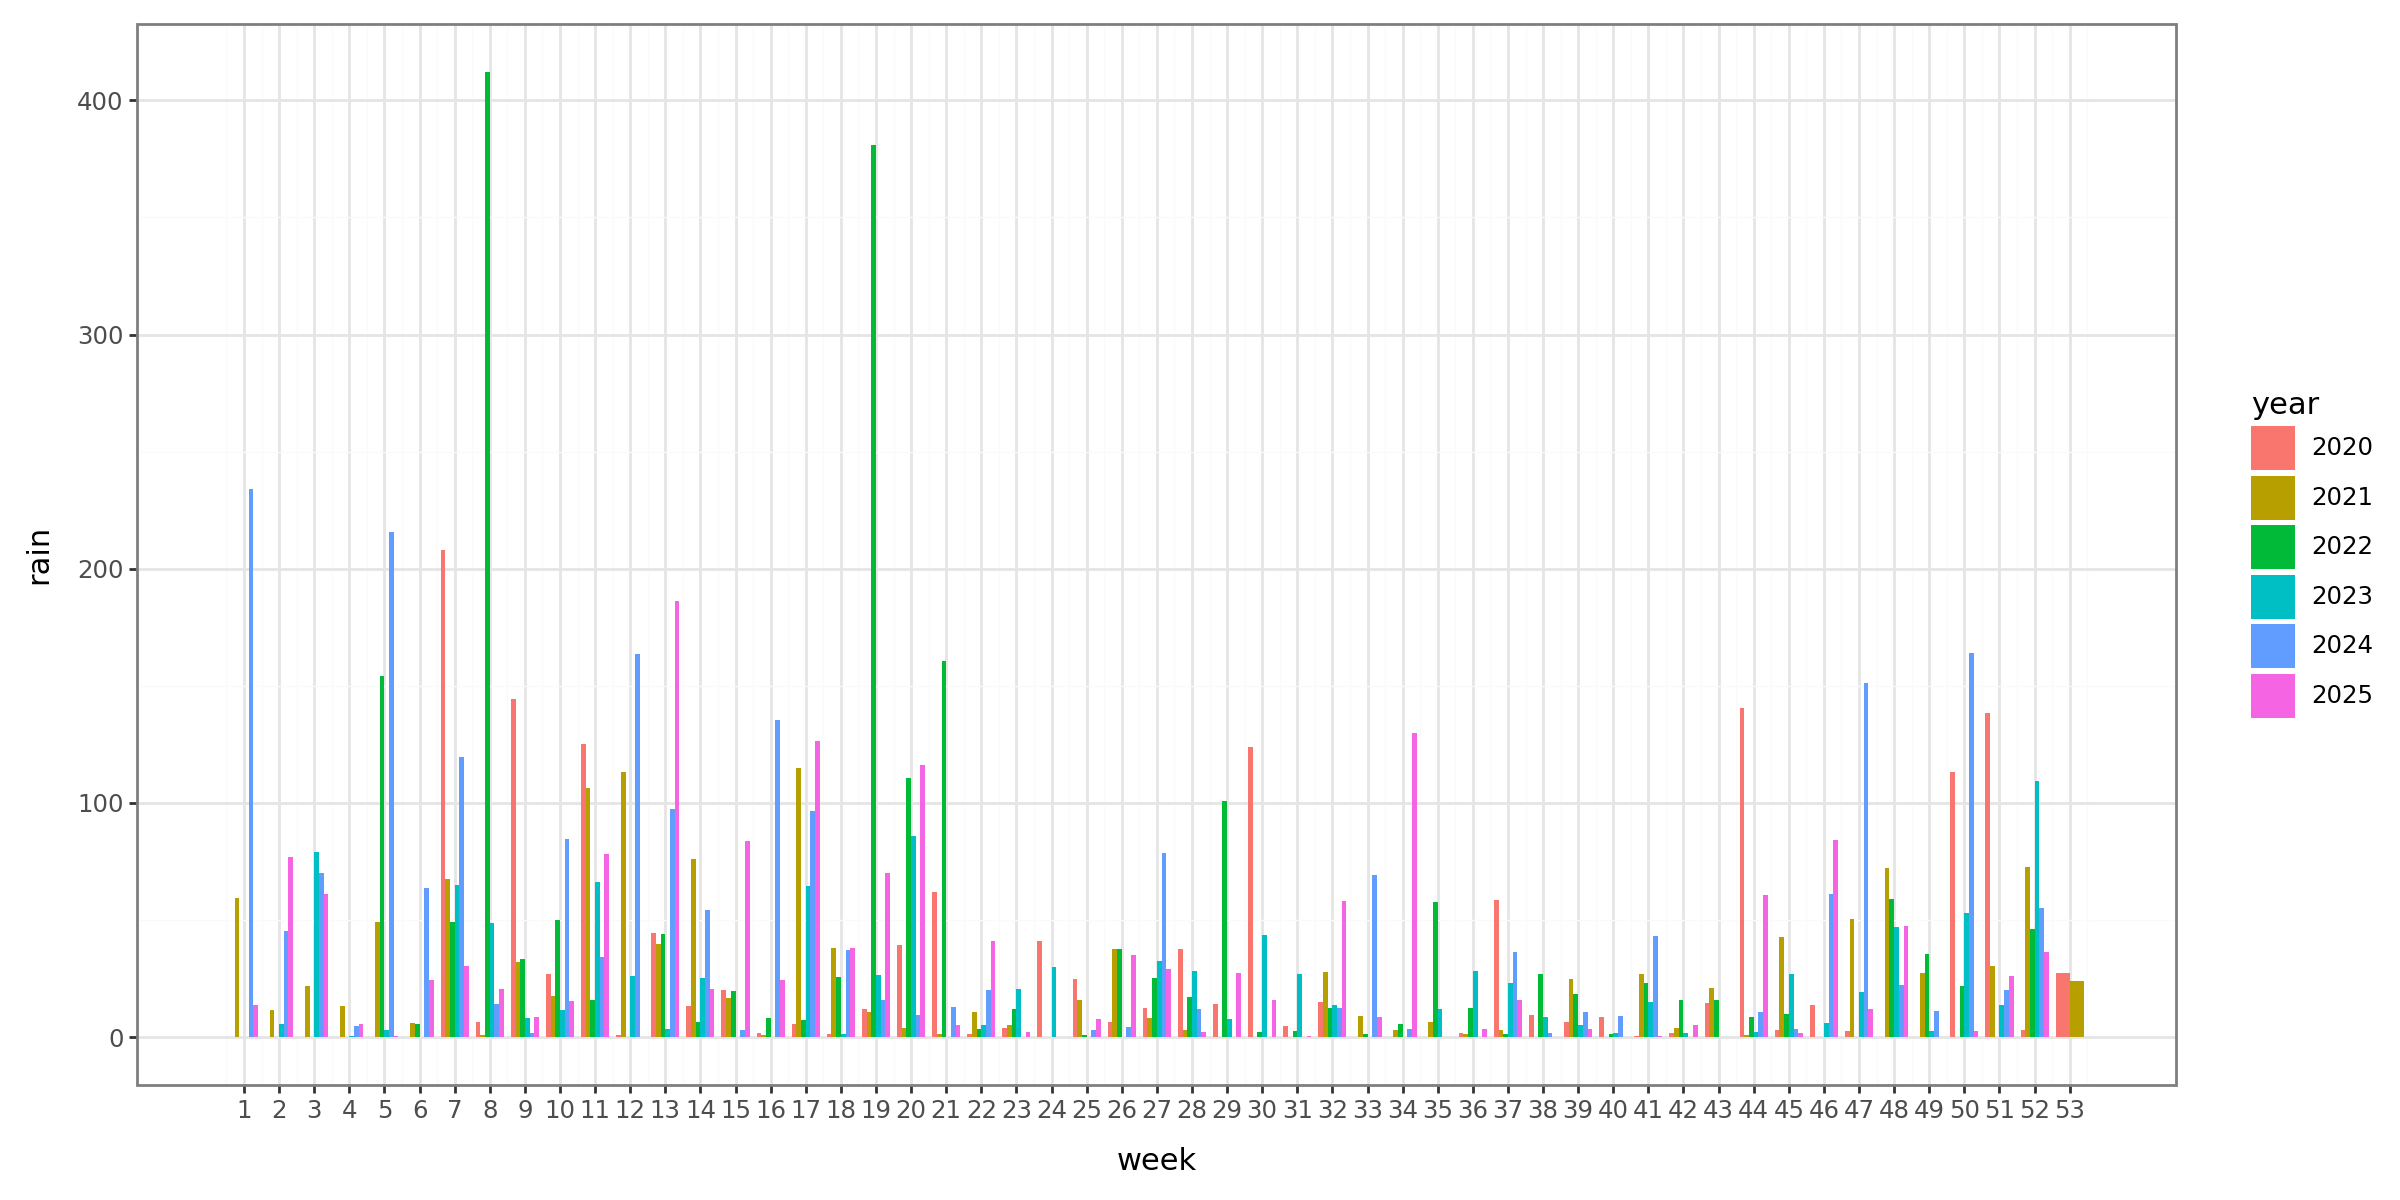

In [24]:
p1 = (
    p9.ggplot(data=w_rain)
    + p9.geom_col(
        mapping=p9.aes(
            x='week', y='rain', fill='year'
        ),  # color each bar depending upon the year
        position='dodge',  # set bars to be side by side (not stacked)
        width=0.8,
    )
    + p9.theme_bw()  # go with pure black / white theme
    + p9.theme(
        figure_size=(width, height),
    )
    + p9.scale_x_continuous(
        breaks=list(range(1, 54))
    )  # ensure all week numbers appear
)
p1

-----------------

## iPad comparison

The plot below is the iPad version of the plot above.  I must say that I prefer my hand-selected palette, to the default Plotnine palette.  Note that some weekly rainfall bars are different between the two plots (as described above)

![](images/weekly_bar.png)

-------------------

## One-per-year weekly rainfall plots

We can use the __facet_wrap__ Plotnine method to effectively say: make a seperate plot as specified,  for each subset of the data that has the same __year__ value, and align these subplots in three columns

Set the labels to be created in our subplots.  Plotnine will apply the year label to distinguish the subplots, so we don't need to do this

In [25]:
labels = p9.labs(
    y='Rain (mm)',
    x='Week',
    caption='Coolum Beach rain gauge',
    subtitle=f'Rainfall by week, 2020-2025',
)
height = 8

We:

+ create an empty plot object, setting our data source to be the weekly rain DataFrame w_rain
+ add columns, x-axis position mapped to the week column, height mapped to the rain column
+ set the columns to be side by side (not stacked)
+ set the column width to leave a small space between weeks
+ set the fill color to be light blue (every bar has the same color)
+ set for a set of subplots (one for each year), in three columns
+ set the y axis limits to be the same for each subplot
+ set a theme of black & white (no gray fill)
+ set the plot size in a __theme__ call
+ set the x axis tick marks and tick labels to be values between 1 and 53 in steps of 10
+ set the labels on the plot

C:\Users\donrc\anaconda3\envs\r_python\Lib\site-packages\plotnine\layer.py:374: PlotnineWarning: geom_col : Removed 1 rows containing missing values.


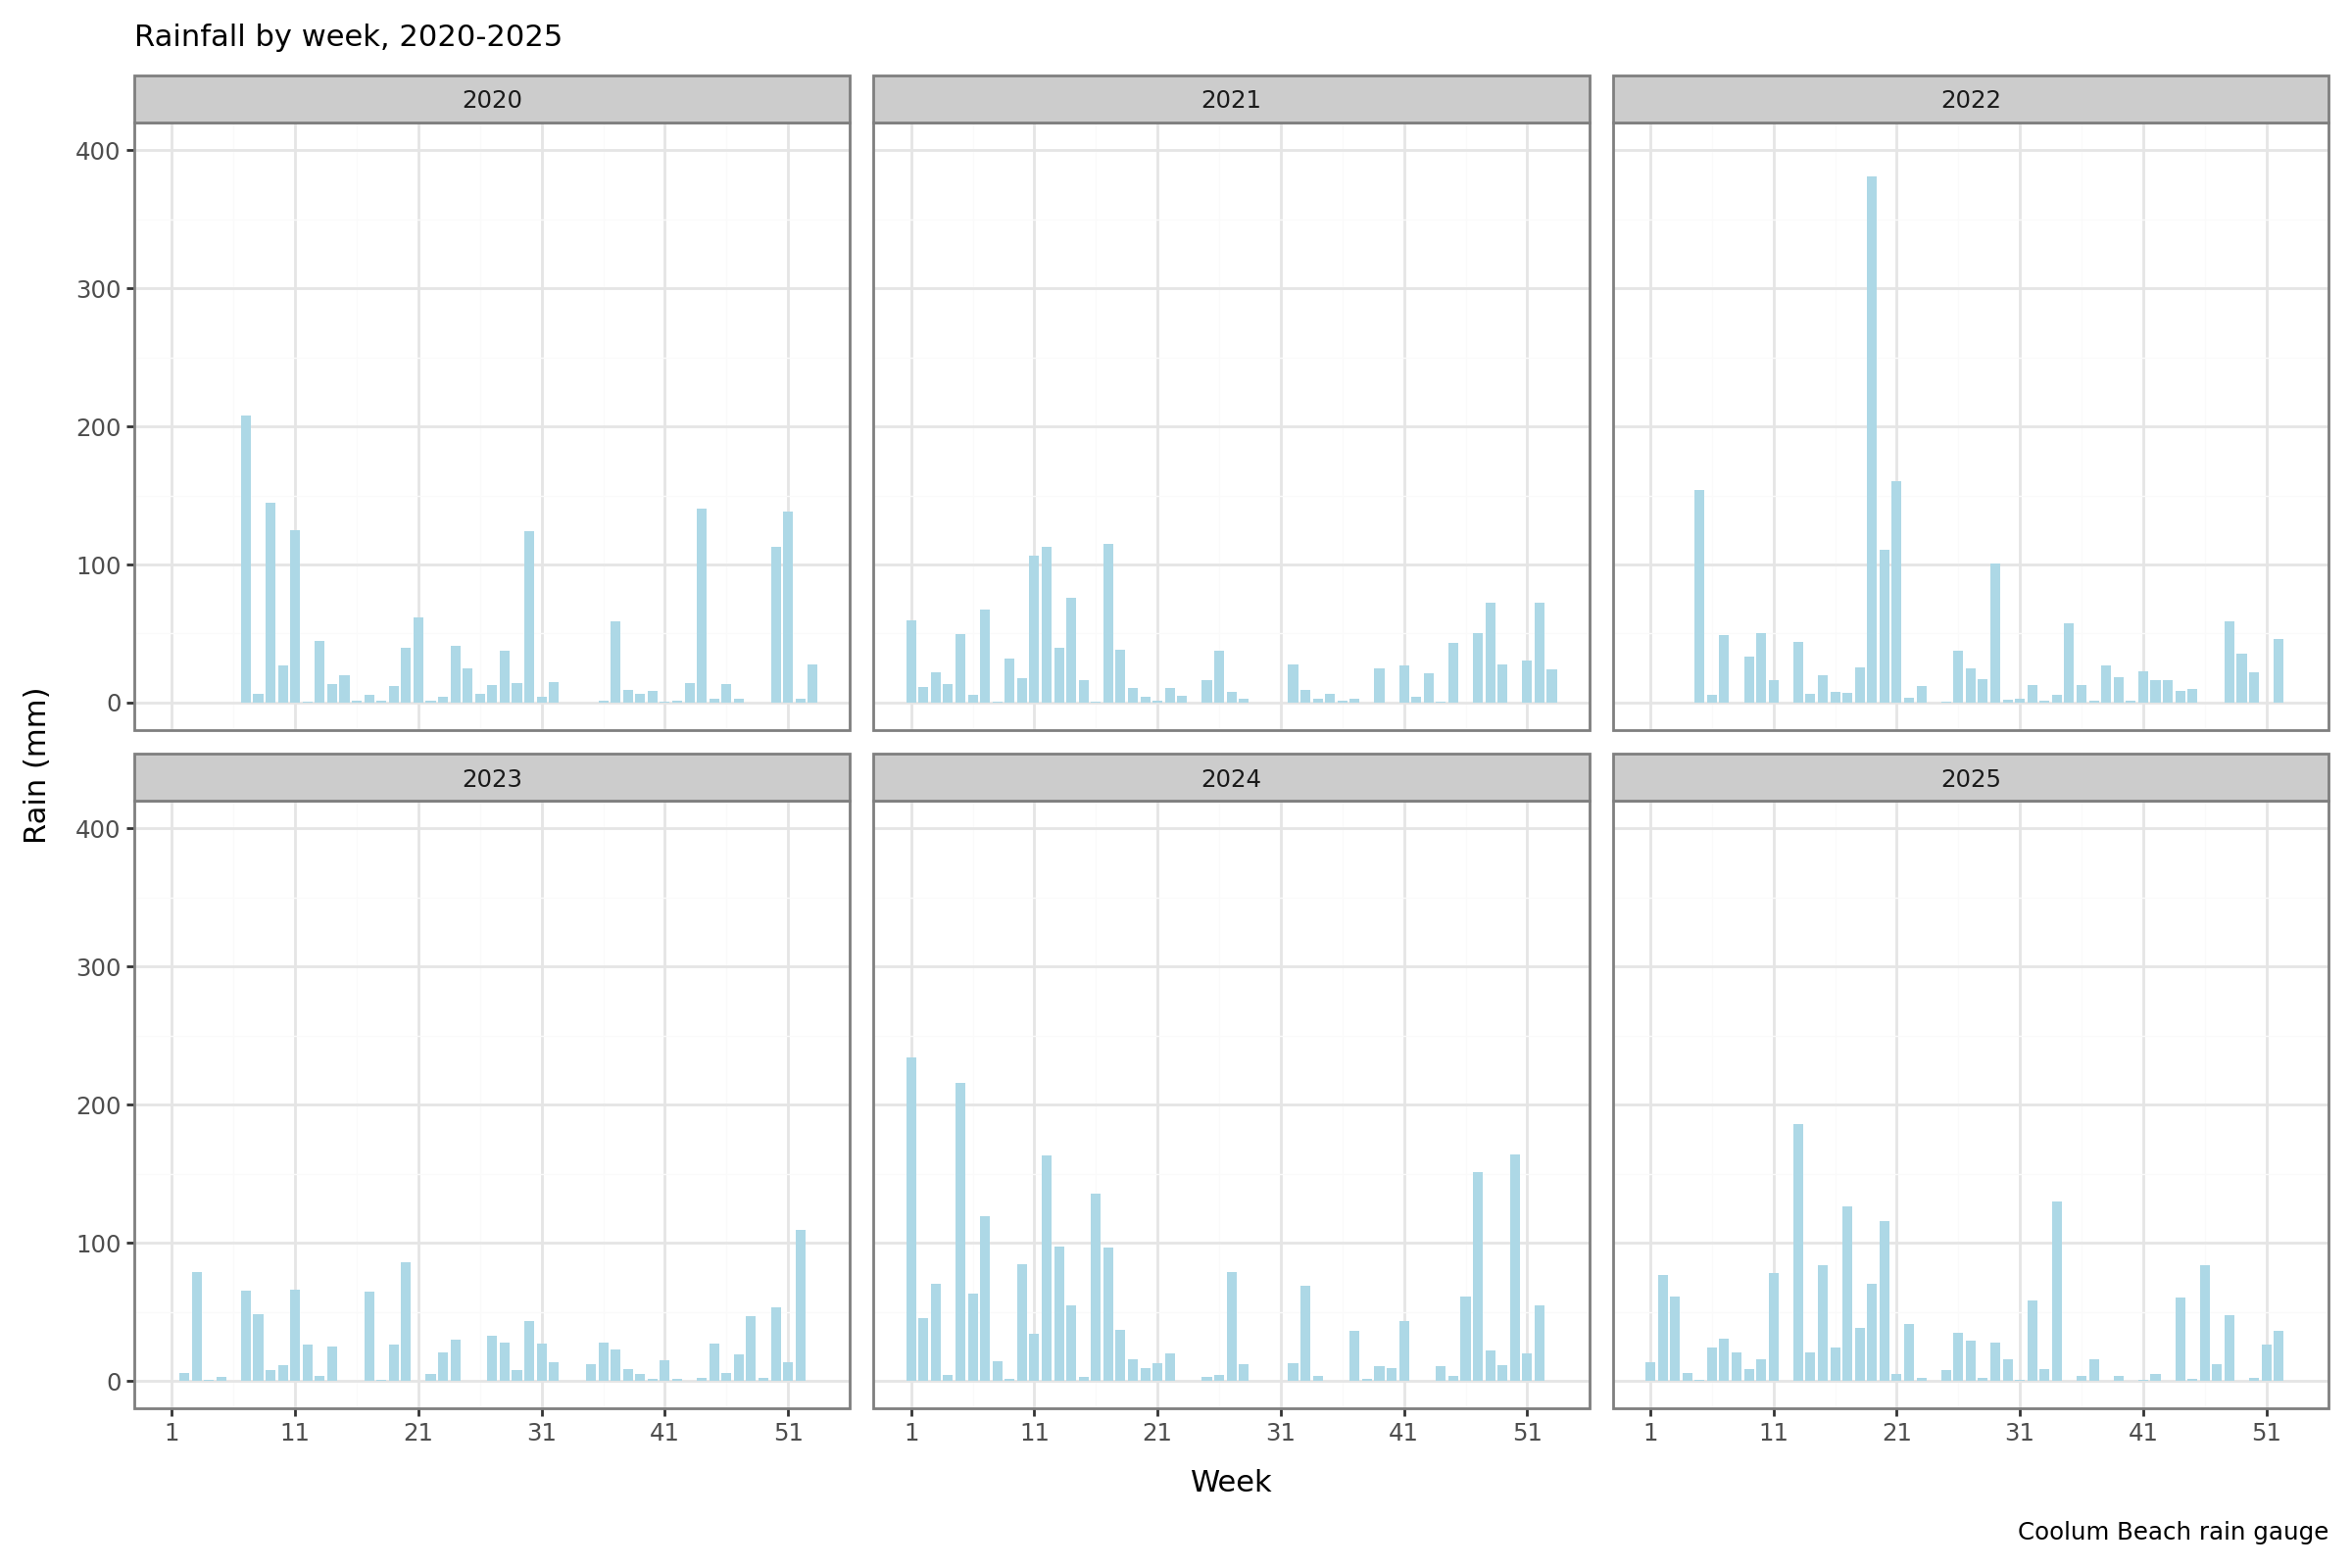

In [26]:
p1 = (
    p9.ggplot(data=w_rain)
    + p9.geom_col(
        mapping=p9.aes(
            x='week',
            y='rain',
        ),
        position='dodge',
        width=0.8,
        fill='lightblue',
    )
    + p9.facet_wrap('year', ncol=3)
    + p9.ylim((0, 400))
    + p9.theme_bw()
    + p9.theme(
        figure_size=(width, height),
    )
    + p9.scale_x_continuous(breaks=list(range(1, 54, 10)))
    + labels
)
p1

---------------------

## iPad comparison

The plot below is the iPad version of the plpot above.  I prefer the Plotnine version

![](images/weekly_mini.png)

-----------------------------------
## Weekly statistics

As before with quarters and months, we made up a DataFrame with a column holding the lowest, average, and highest rainfall for that week number of the year

In [27]:
w_max = []
w_min = []
w_avg = []

for w in range(1, 54):
    v_max = w_rain[w_rain['week'] == w]['rain'].max()
    v_min = w_rain[w_rain['week'] == w]['rain'].min()
    v_avg = w_rain[w_rain['week'] == w]['rain'].mean()

    w_max.append(v_max)
    w_min.append(v_min)
    w_avg.append(v_avg)
# end for

w_stats_df = pd.DataFrame(
    {
        'week': list(range(1, 54)),
        'min': w_min,
        'avg': w_avg,
        'max': w_max,
    }
)

Examine the first few rows: look OK

In [28]:
w_stats_df.head()

,week,min,avg,max
0,1,0.0,51.166667,234.0
1,2,0.0,23.200000,77.0
2,3,0.0,38.633333,79.0
3,4,0.0,3.966667,13.3
4,5,0.0,70.350000,215.5


We:
+ define the labels we want for each plot (one plot per summary statistic).
+ define the name of the column holding the data appropriate for each label
+ define the saturation (alpha) for the bars in each plot

In [29]:
label_min = p9.labs(
    y='Rain (mm)',
    x='week',
    caption='Coolum Beach rain gauge (2020-2025)',
    subtitle='Lowest weekly rain',
)
label_max = p9.labs(
    y='Rain (mm)',
    x='week',
    caption='Coolum Beach rain gauge (2020-2025)',
    subtitle='Highest weekly rain',
)
label_avg = p9.labs(
    y='Rain (mm)',
    x='week',
    caption='Coolum Beach rain gauge (2020-2025)',
    subtitle='Average weekly rain',
)
labels = [label_min, label_avg, label_max]
col_names = ['min', 'avg', 'max']
alphas = [0.5, 0.7, 1.0]
height = 8

We loop over the summary statistics, and build a list of plots

In [30]:
plots = []

for name, label, a in zip(col_names, labels, alphas):
    p1 = (
        p9.ggplot(data=w_stats_df)
        + p9.geom_col(
            mapping=p9.aes(y=name, x='week'),
            fill='lightblue',
            alpha=a,
        )
        + p9.coord_flip()
        + p9.ylim((0, 400))
        + label
        + p9.theme_bw()
        + p9.theme(
            figure_size=(width, height),
            panel_grid_major_y=p9.element_blank(),
            panel_grid_minor_y=p9.element_blank(),
        )
    )
    plots.append(p1)
# end for

Show the plots side by side

C:\Users\donrc\anaconda3\envs\r_python\Lib\site-packages\plotnine\layer.py:358: PlotnineWarning: position_stack : Removed 1 rows containing missing values.


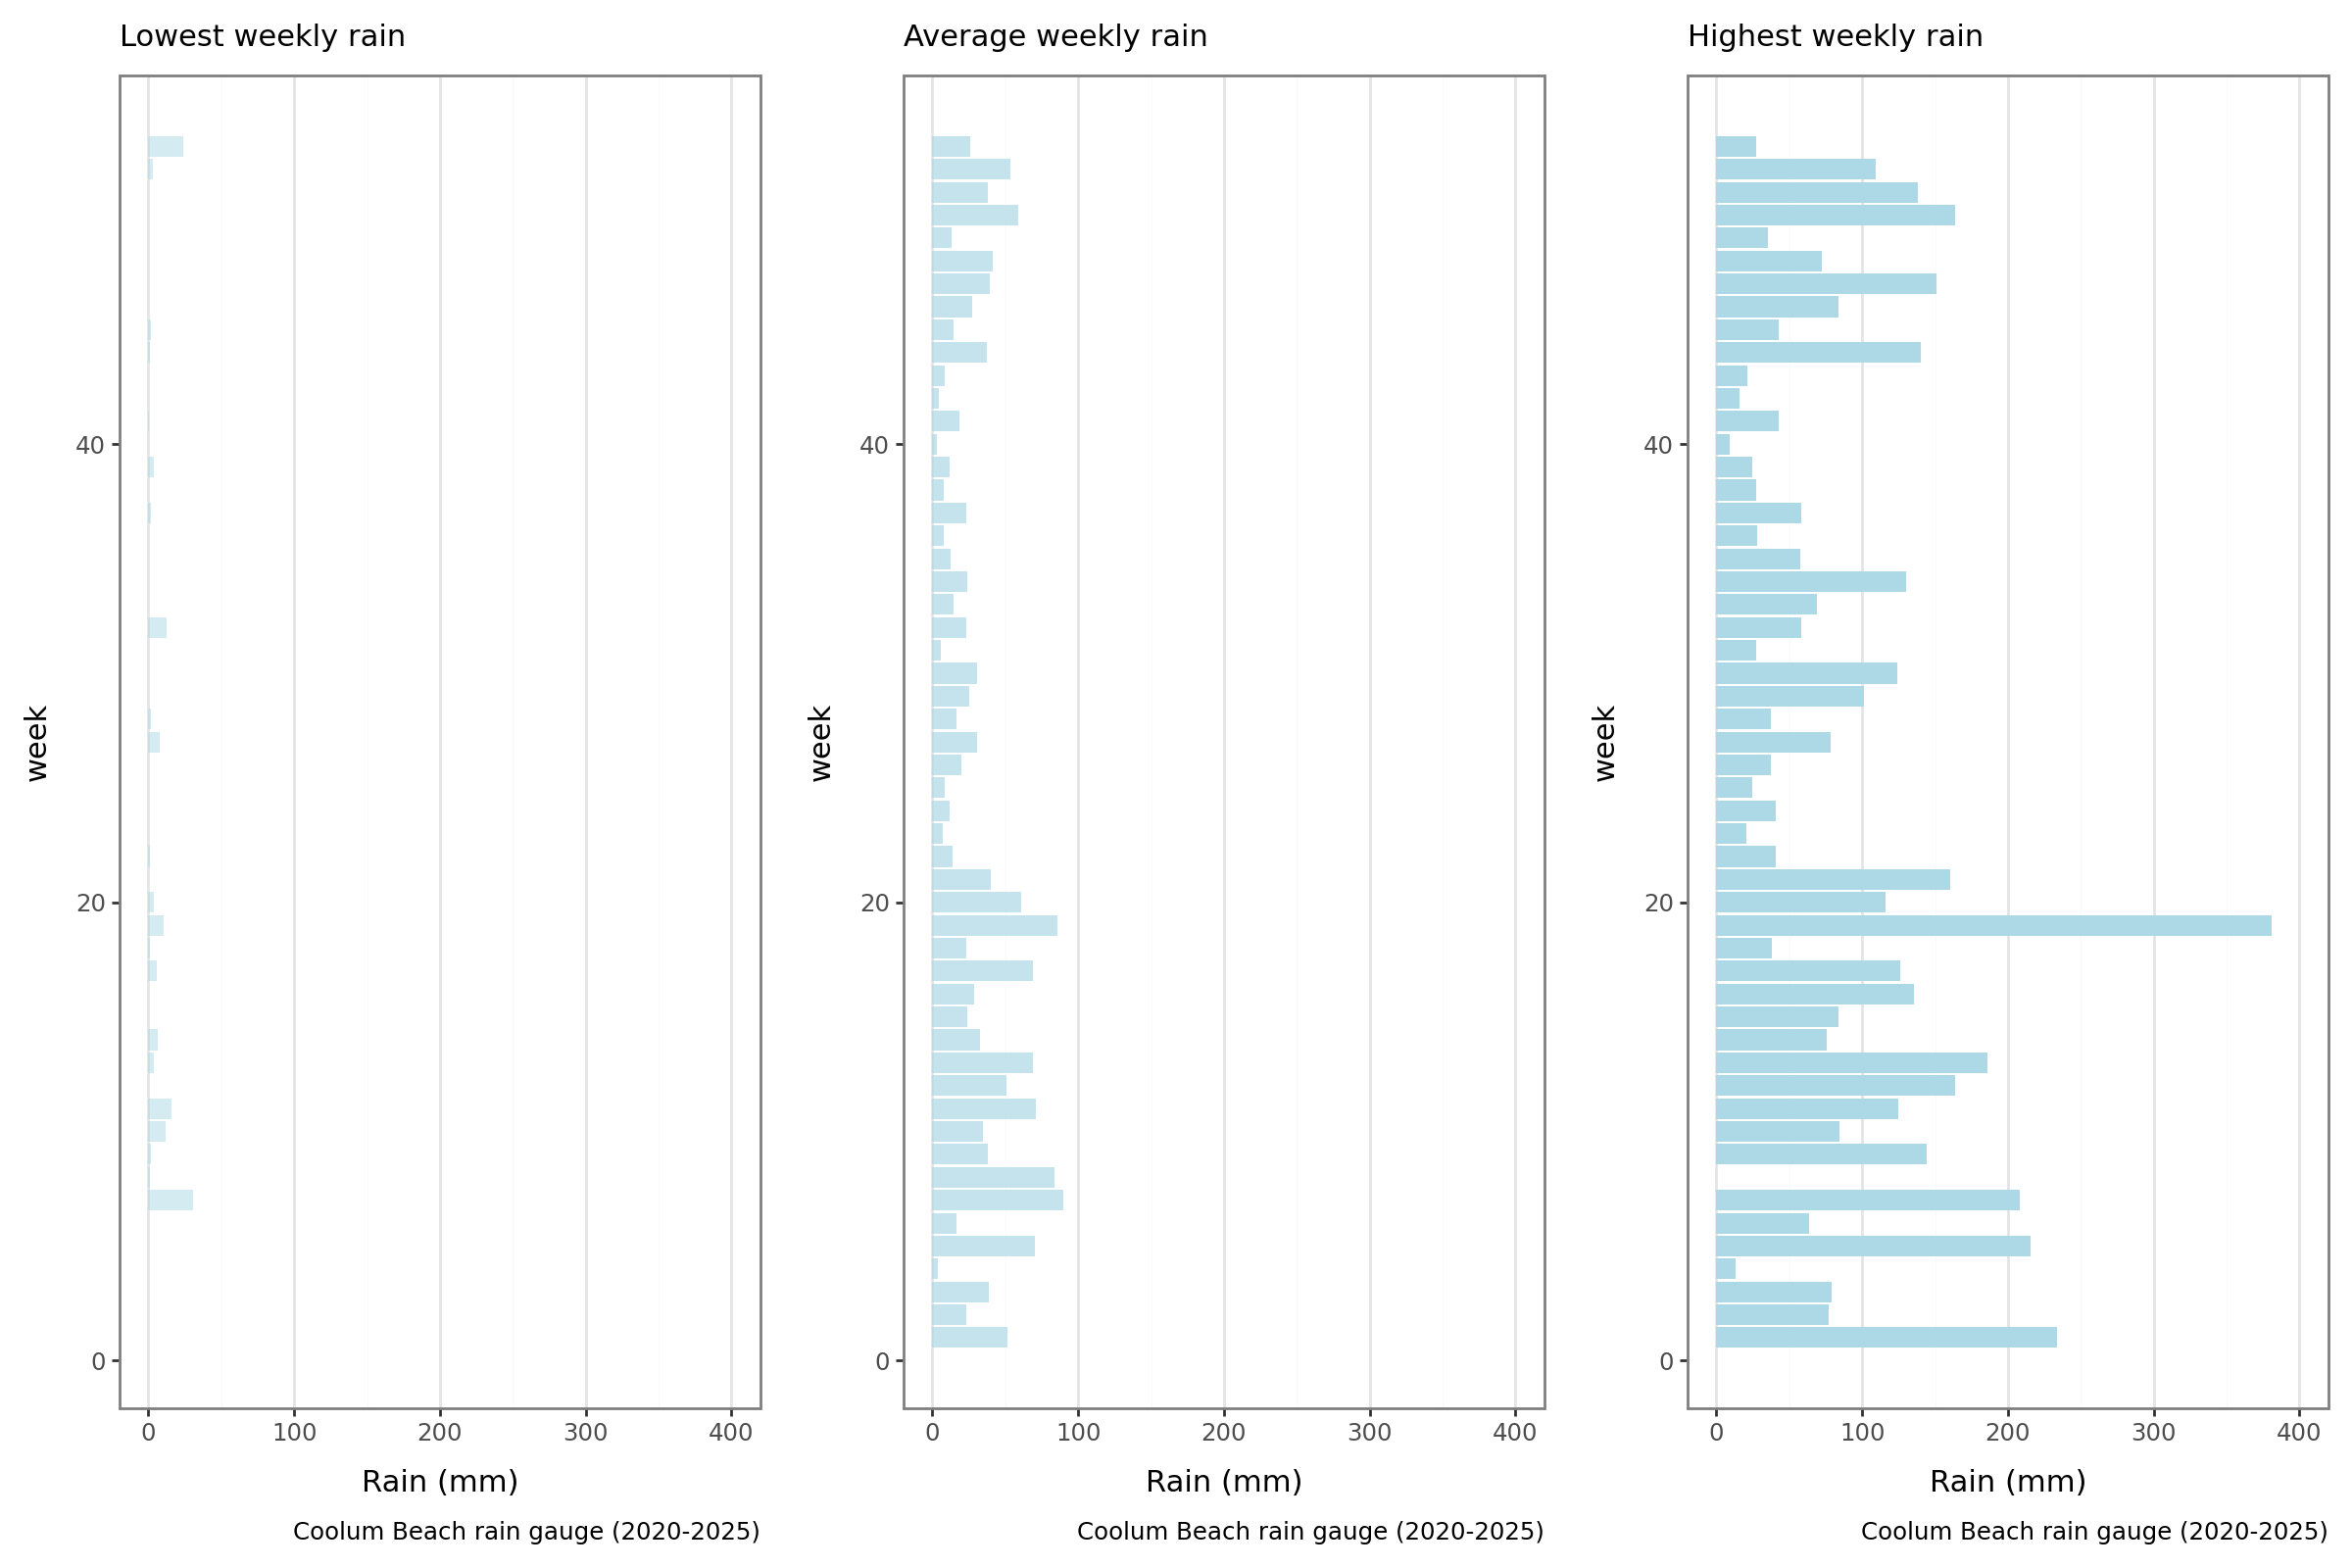

In [31]:
(plots[0] | plots[1] | plots[2])

------------------------------

## Dry weeks

I thought it might be interesting to visualize the number of dry weeks in each year

This will serve as an opportunity to demonstrate a Plotnine hack for legends

Refresh our memory of the weekly rainfall DataFrame

In [32]:
w_rain.tail(3)

,year,week,rain
311,2025,50,2.5
312,2025,51,26.0
313,2025,52,36.5


In [33]:
dry_weeks = []
for y in range(2020, 2026):  # for all years of interest
    # select the rows with rain==0, and count then
    c = w_rain[
        (w_rain['year'] == y) & (w_rain['rain'] <= 0.0)
    ]['rain'].count()
    dry_weeks.append(c)  # add the list of dry weeks counts
# end for
# build DataFrame holding dry week count for each year
dry_df = pd.DataFrame(
    {'year': list(range(2020, 2026)), 'dry': dry_weeks}
)
dry_df

,year,dry
0,2020,11
1,2021,8
2,2022,9
3,2023,10
4,2024,9
5,2025,7


Set the labels we want on the plot

In [34]:
label = p9.labs(
    y='count',
    x='year',
    caption='Coolum Beach rain gauge',
    title='Count of dry weeks, 2020-2025',
)

We:
+ create an empty plot
+ add a layer of columns, with
    + x-axis mapped to column __year__,
    + y-axis mapped to column __dry__
    + make each layer a tan color
    + set the column width
+ add the plot label
+ add the x-axis tick marks for all years
+ set the theme to be black & white
+ set the figure size, and turn off year gridlines

The subtle point here is that the color is specified __outside__ the __aes__ call, so applies to all columns, but will __not__ appear in a legend (guide in Plotnine terminology).  If we had ```fill='tan'```inside the __aes__ call, Plotnine expects to find a column __tan__ in the source DataFrame.

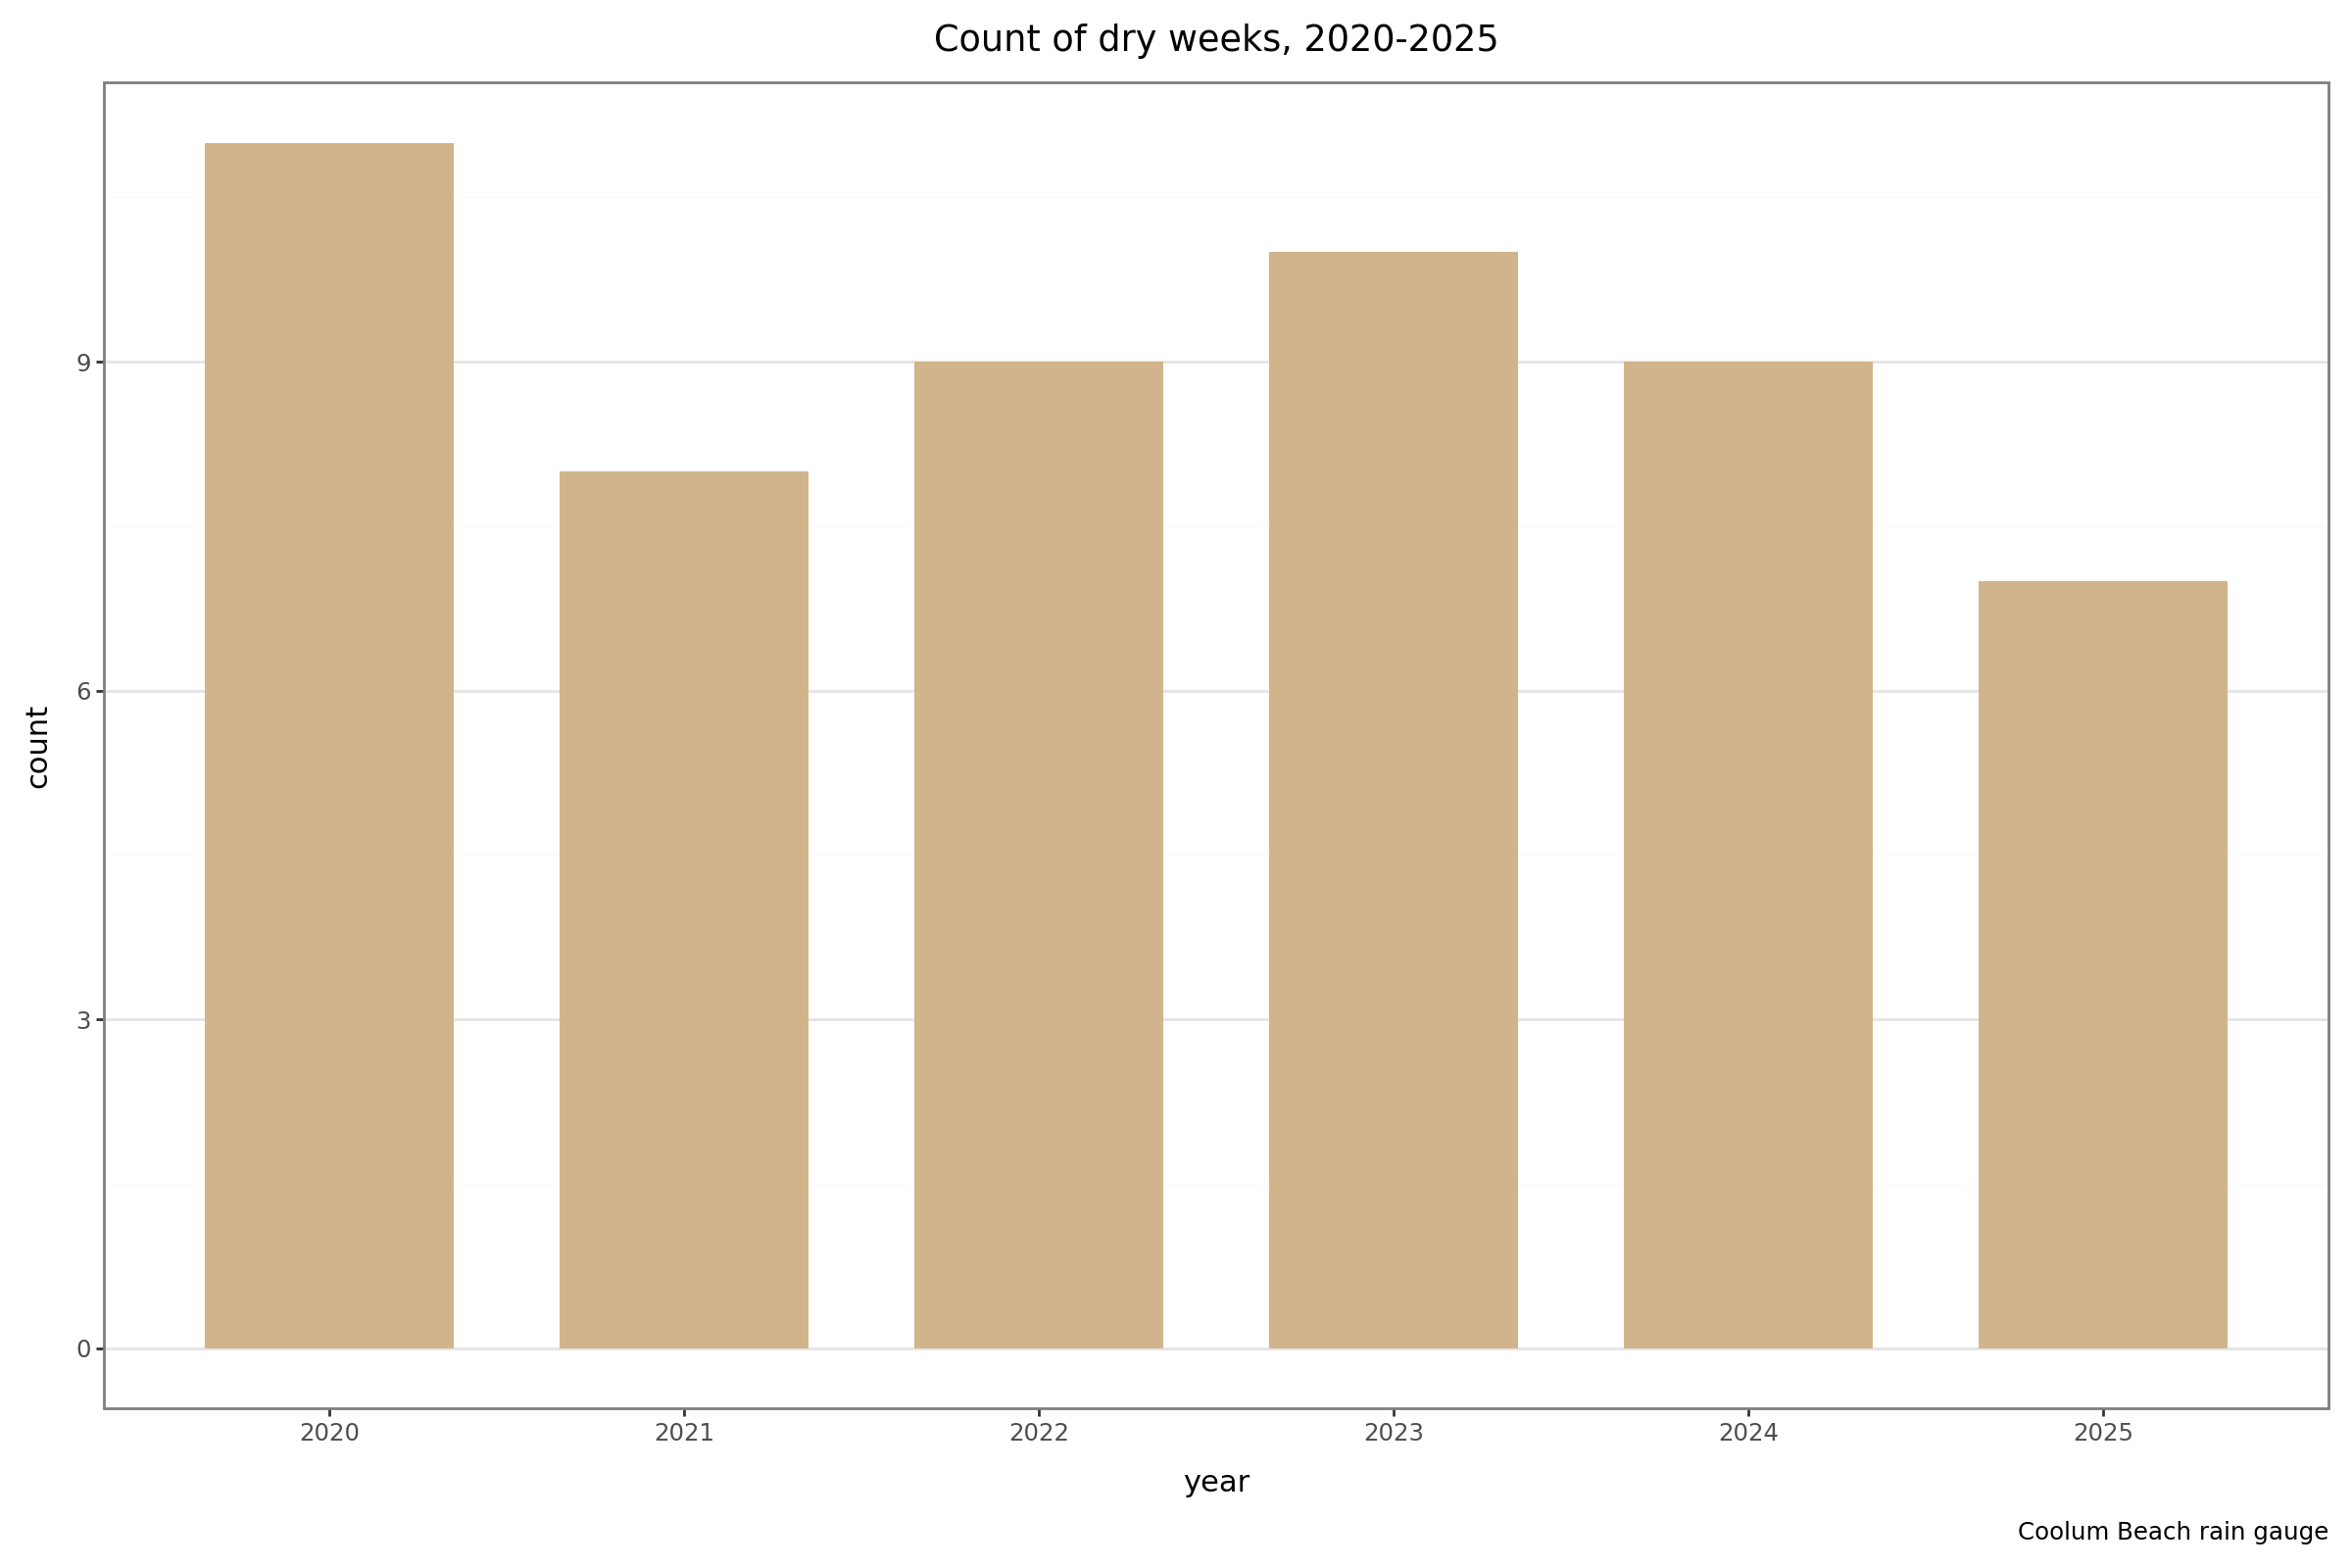

In [35]:
p1 = (
    p9.ggplot(data=dry_df)
    + p9.geom_col(
        mapping=p9.aes(y='dry', x='year'),
        fill='tan',
        width=0.7,
    )
    + label
    + p9.scale_x_continuous(breaks=list(range(2020, 2026)))
    + p9.theme_bw()
    + p9.theme(
        figure_size=(width, height),
        panel_grid_major_x=p9.element_blank(),
        panel_grid_minor_x=p9.element_blank(),
    )
)
p1

_____________

## Plotnine hack or inspired moment?

Suppose we want a legend to explain our color choice?

If inside the __aes__ call, we set the fill parameter to a double wrapped string, then Plotnine knows it __not__ a DataFrame column, but a color name constant.

The method __scale_fill_identity__:
+ specifies the mapping between the source of fill-related attributes (in this case a constant string, but usually a DataFrame column), and the actual fill used,
+ the __identity__ part of the function name says use the fill-related attribute as a color name (here, the string ```'tan```)
+ the name parameter defines what label appears over the legend part of the plot
+ the guide parameter says which scale guide is being set up (in this case the fill legend)
+ the breaks parameter says how many items we want to be labelled in the legend
+ the labels parameter gives the labels for each labelled item in the lehend

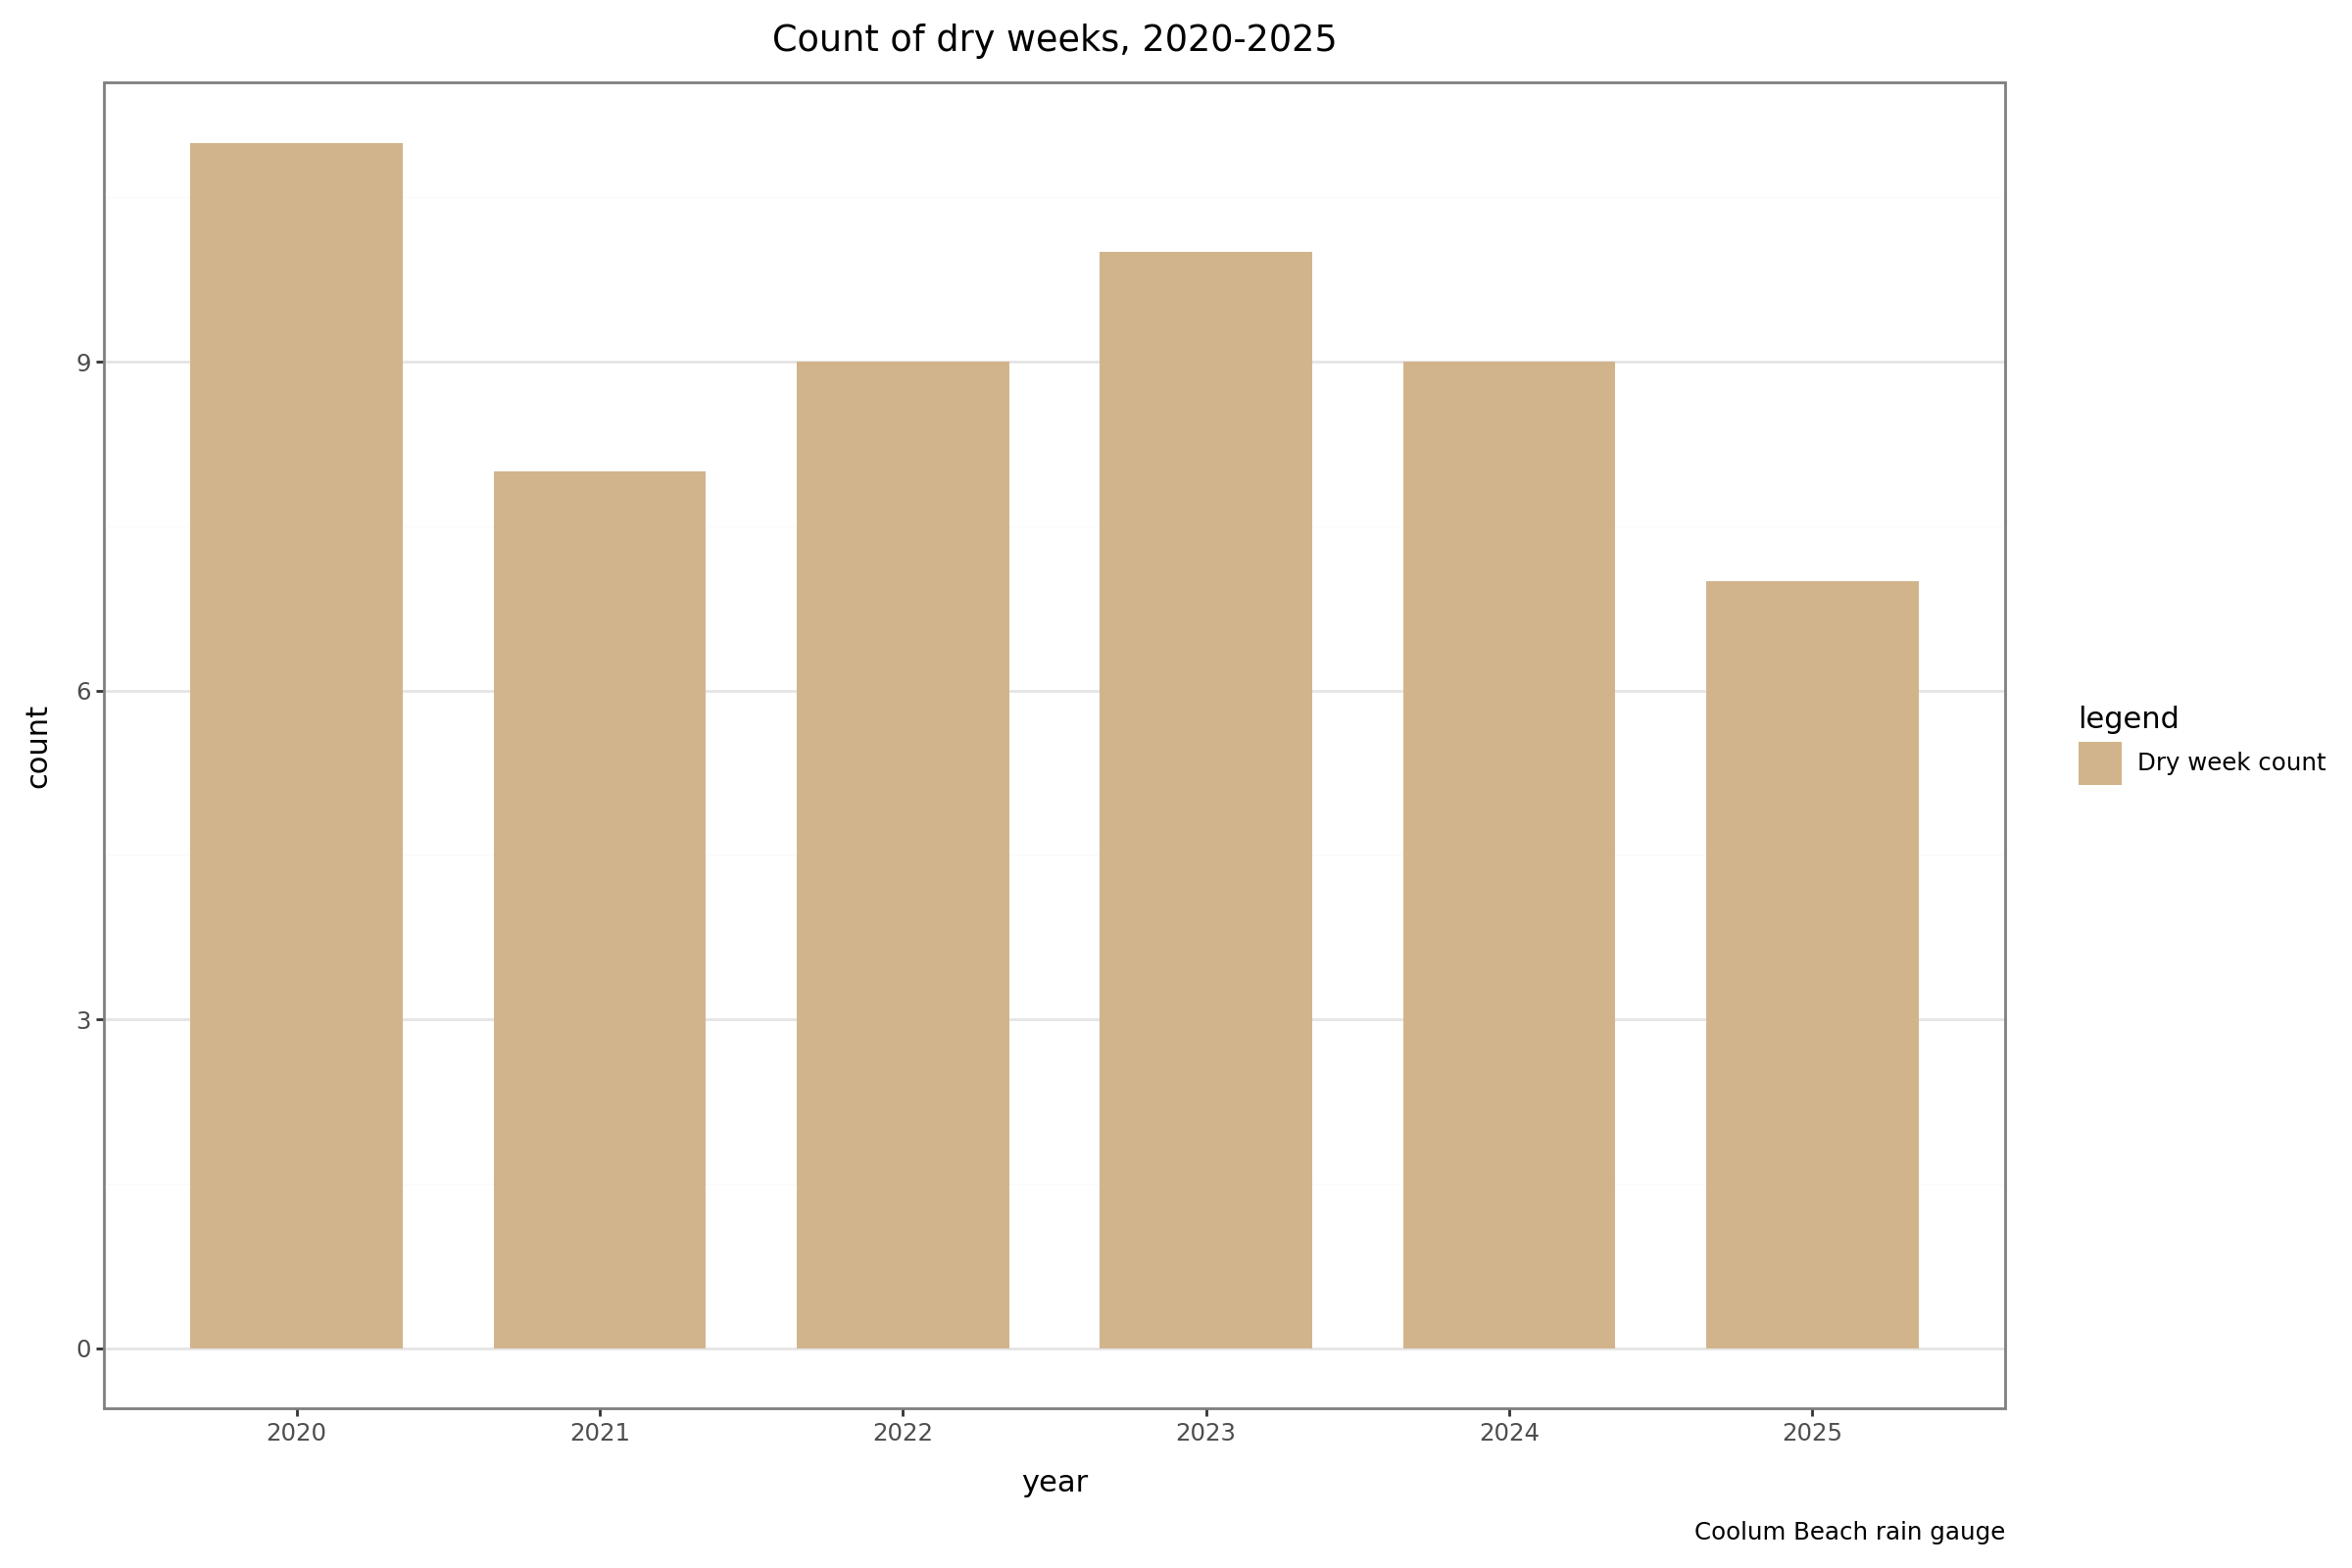

In [36]:
p1 = (
    p9.ggplot(data=dry_df)
    + p9.geom_col(
        mapping=p9.aes(y='dry', x='year', fill='"tan"'),
        width=0.7,
    )
    + label
    + p9.scale_x_continuous(breaks=list(range(2020, 2026)))
    + p9.theme_bw()
    + p9.theme(
        figure_size=(width, height),
        panel_grid_major_x=p9.element_blank(),
        panel_grid_minor_x=p9.element_blank(),
    )
    + p9.scale_fill_identity(
        name='legend',
        guide='legend',
        breaks=[
            'tan',
        ],
        labels=[
            'Dry week count',
        ],
    )
)
p1

---------------------
## Box-and-whiskers plot

This style of plot does not appear in my iPad spreadsheet.  It seems intuitive, showing the spread of monthly rainfall values across all years.  Then you ask "what are the few visible points": Answer:

    The lower bottom and upper top of the boxes correspond to the first and third quartiles (the 25th and 75th percentiles). 
    
    The upper whisker extends from the box top to the largest value no further than 1.5 * IQR from the hinge (where IQR is the inter-quartile range, or distance between the first and third quartiles). The lower whisker extends from the box bottom to the smallest value at most 1.5 * IQR of the hinge. Data beyond the end of the whiskers are called "outlying" points and are plotted individually.

Try explaining all that to a random citizen: boxplots in my view are only for informed audiences  (which may explain why the iPad doesn't support them)

However the hack above can be used to provide an on-plot explanation

As before, create a DataFrameholding monthly rain by year, where the __month__ column is a set of ordered categories.  Check the first few rows.

In [37]:
rain_df2['month'] = rain_df2['date'].dt.month_name()
months = [
    'January',
    'February',
    'March',
    'April',
    'May',
    'June',
    'July',
    'August',
    'September',
    'October',
    'November',
    'December',
]
rain_df2['month'] = (
    rain_df2['month'].astype('str').astype('category')
)
rain_df2['month'] = rain_df2[
    'month'
].cat.reorder_categories(months, ordered=True)

m_sum = rain_df2.groupby(['month', 'year'], observed=False)[
    'rain'
].sum()

m_sum_df = pd.DataFrame(m_sum)

m_sum_df2 = m_sum_df.reset_index(level=['month', 'year'])

m_sum_df2.head()

,month,year,rain
0,January,2020,0.0
1,January,2021,129.9
2,January,2022,23.0
3,January,2023,86.5
4,January,2024,551.4


Process flow is:

+ set labels and titles
+ create an empty plot declaring our default data source to be our monthly summed DataFrame
+ create a layer with a boxplot, with __month__ mapped to the x-axis, __rain__ mapped to the y-axis
+ fill all boxplot boxes lightblue (i.e. a constant color string double-wrapped), not mapped to any variable.  This appears __inside__ the __aes__ call, so will create a __fill__ legend
+ set boxplot outlier point color to red
+ create a dummy layer with one red point of negative rain (won't appear on plot, because we hide negative rain values), but the __color__ parameter is used __inside__ the __aes__ call, so creates a color legend.
+ select a black-white theme
+ set the plot size, and turn off vertical gridlines (months) with a theme call
+ set the labels
+ __scale_fill_identity__ sets up the fill legend (see above)
+ __scale_fill_color__ sets up the color legend (as above)  Note that Plotnine treats __fill__ and __color__ as two different ideas
+ set the y-axis limits to hide the dummy rain point layer

C:\Users\donrc\anaconda3\envs\r_python\Lib\site-packages\plotnine\layer.py:374: PlotnineWarning: geom_point : Removed 72 rows containing missing values.


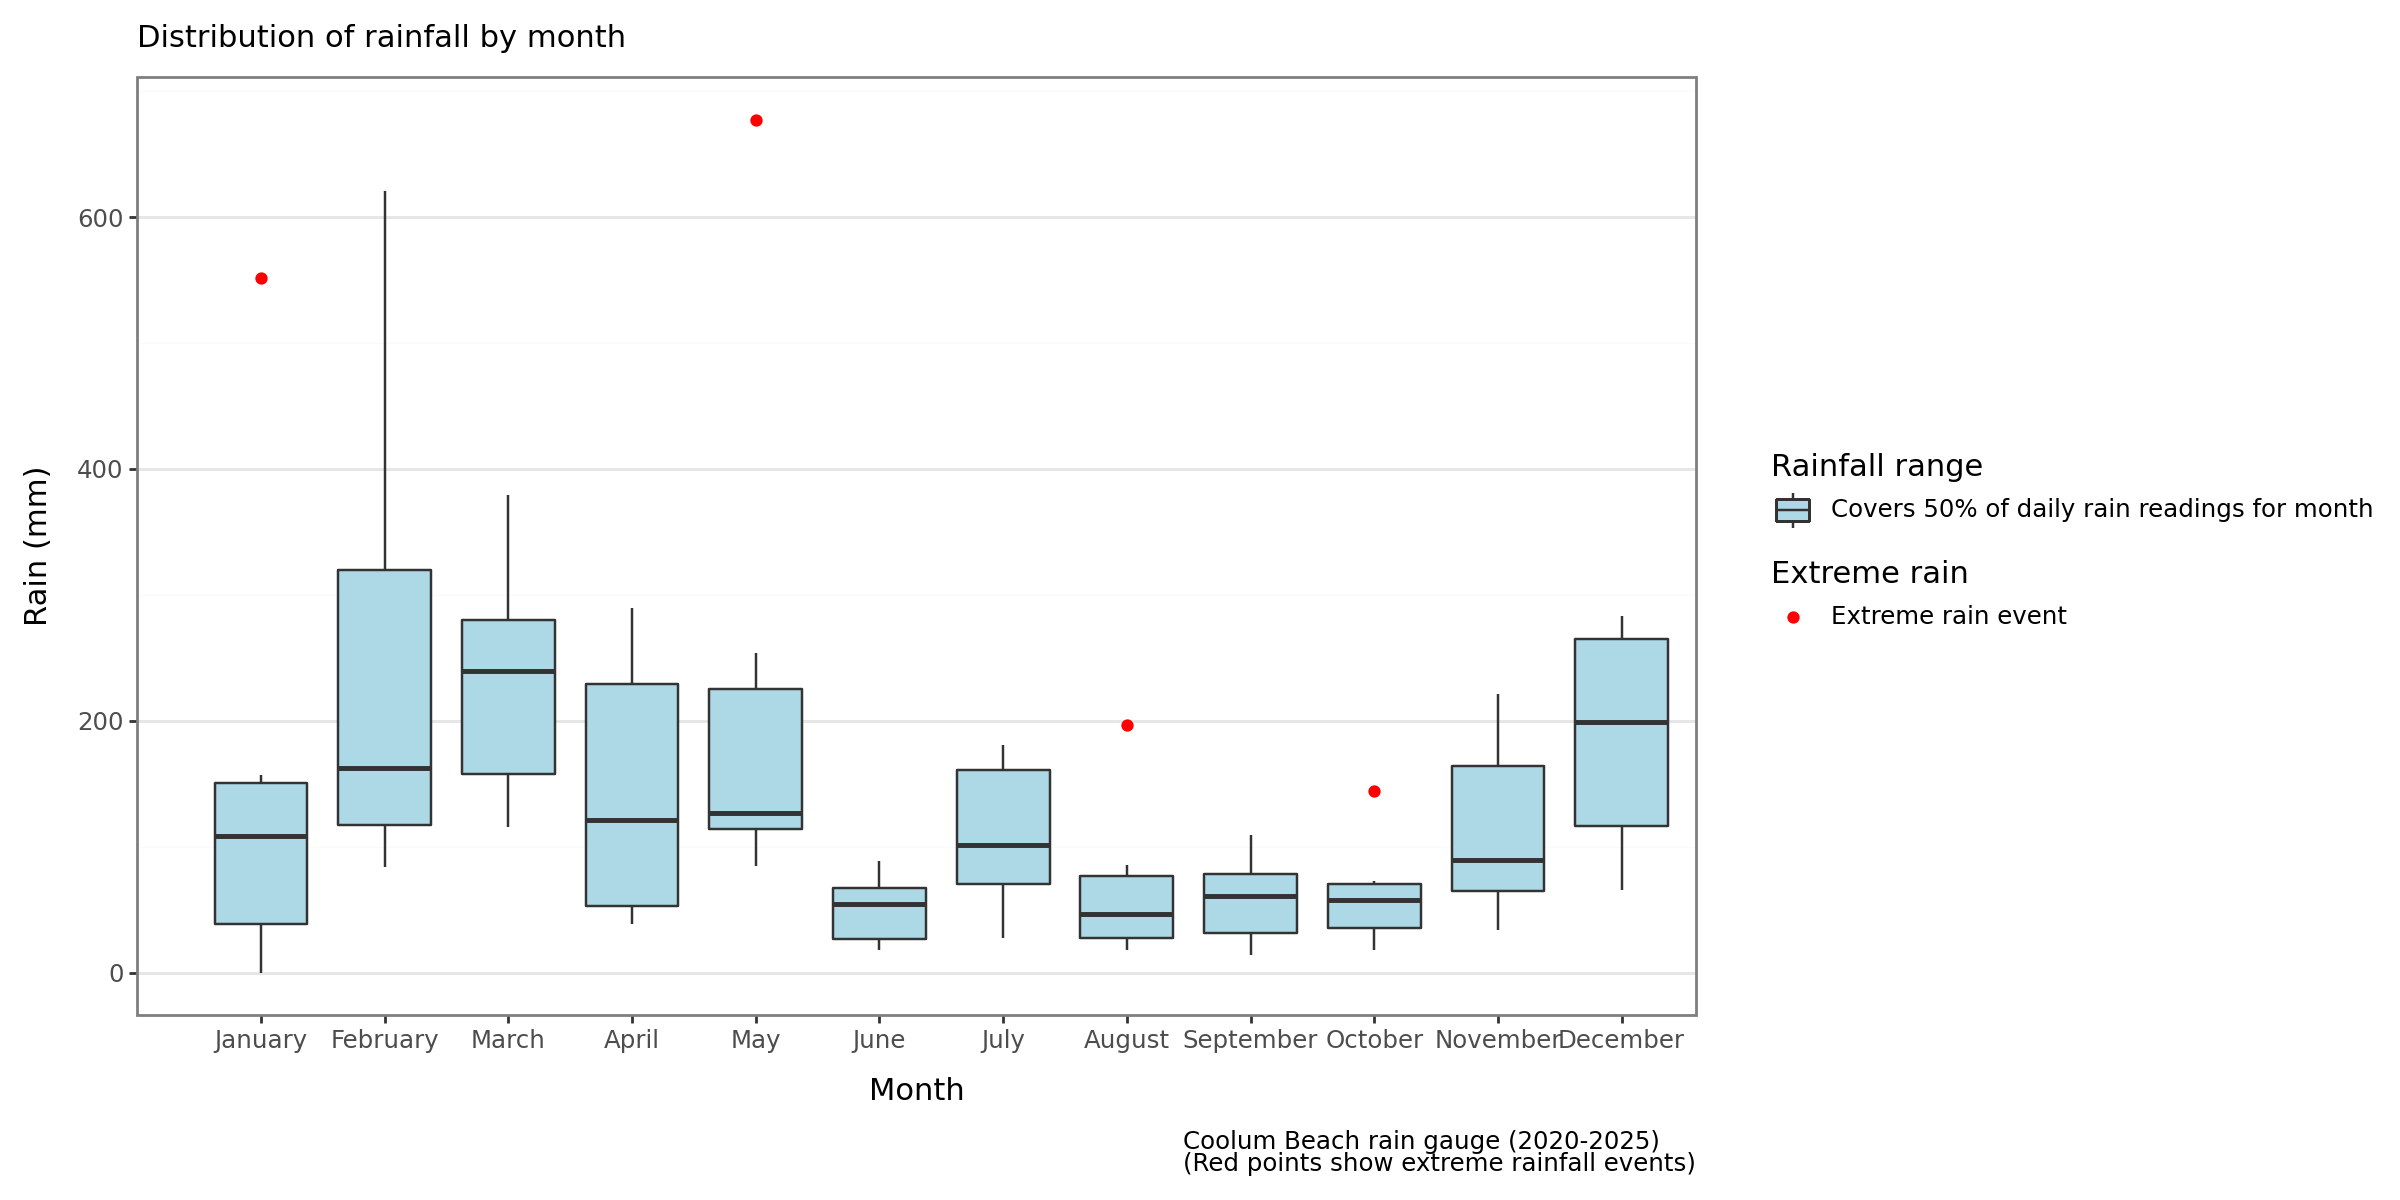

In [38]:
width, height = (12, 6)

labels = p9.labs(
    y='Rain (mm)',
    x='Month',
    caption='Coolum Beach rain gauge (2020-2025) \n(Red points show extreme rainfall events)',
    subtitle='Distribution of rainfall by month',
)

p1 = (
    p9.ggplot(
        data=m_sum_df2,
    )
    + p9.geom_boxplot(
        mapping=p9.aes(
            x='month',
            y='rain',
            fill='"lightblue"',
        ),
        outlier_color='red',
    )
    + p9.geom_point(  # create layer with points
        mapping=p9.aes(x=[0], y=[-1], color='"red"')
    )
    + p9.theme_bw()
    + p9.theme(
        figure_size=(width, height),
        panel_grid_major_x=p9.element_blank(),
        panel_grid_minor_x=p9.element_blank(),
    )
    + labels
    + p9.scale_fill_identity(
        name='Rainfall range',
        guide='legend',
        breaks=['lightblue'],
        labels=[
            'Covers 50% of daily rain readings for month',
        ],
        drop=False,
    )
    + p9.scale_color_identity(
        name='Extreme rain',
        guide='legend',
        breaks=['red'],
        labels=[
            'Extreme rain event',
        ],
        drop=False,
    )
    + p9.ylim((0, None))
)
p1

------------------------
## Conclusions

Plotnine repays the quite steep learning curve, but there are occasions when I will fall back to Seaborn

-----------------------

In [39]:
%watermark

Last updated: 2026-01-22T21:32:43.649866+10:00

Python implementation: CPython
Python version       : 3.12.12
IPython version      : 9.7.0

Compiler    : MSC v.1944 64 bit (AMD64)
OS          : Windows
Release     : 11
Machine     : AMD64
Processor   : Intel64 Family 6 Model 170 Stepping 4, GenuineIntel
CPU cores   : 22
Architecture: 64bit



In [40]:
%watermark -h -iv -co

conda environment: r_python

Hostname: INSPIRON16

plotnine: 0.15.2
pandas  : 2.3.3
numpy   : 2.3.5



In [41]:
import ipynbname

try:
    nb_fname = ipynbname.name()
    print(f'Notebook file name: {nb_fname}')
except FileNotFoundError:
    print(
        "Could not determine notebook name. Ensure the notebook is saved."
    )

Notebook file name: Rainfall3
